# Plotting using the Mapping API

`Mapping` uses the algorithms outlined in [**Algorithms useful for calculating multi-component equilibria, phase diagrams and other kinds of diagrams** (B. Sundman, N. Dupin, B. Hallstedt, Calphad 75 (2021) 102330)](https://doi.org/10.1016/j.calphad.2021.102330) to construct phase diagrams by stepping along phase boundaries.

`binplot` and `ternplot` are thin wrappers around the binary and ternary mapping strategies; however, additional plotting capabilities are available through the `mapping` module.

## Binary phase diagrams with mapping

This shows how to plot a binary phase diagram through mapping as an alternative to binplot.

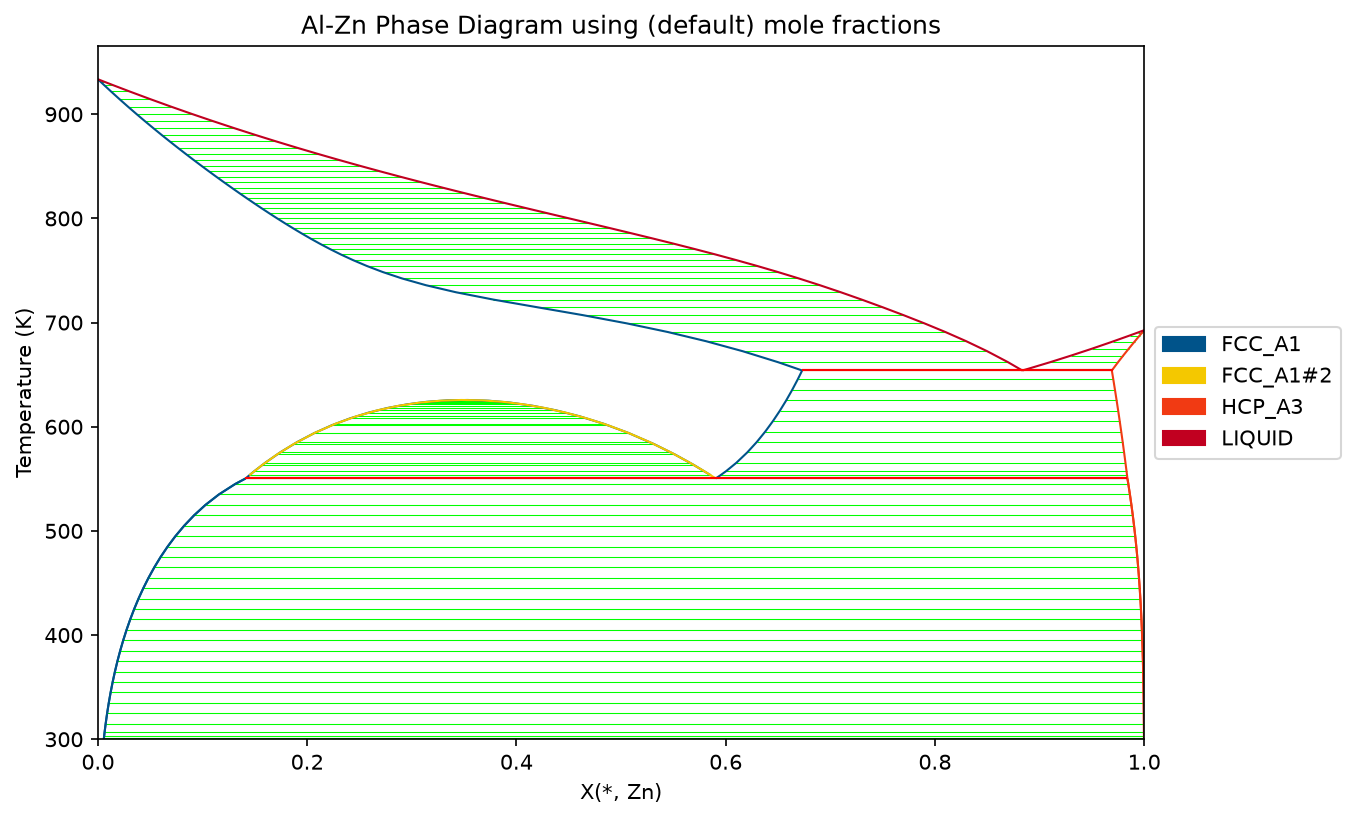

In [1]:
from pycalphad import Database, variables as v
from pycalphad.mapping import BinaryStrategy, plot_binary
import matplotlib.pyplot as plt

dbf = Database('../databases/alzn_mey.tdb')
comps = ['AL', 'ZN', 'VA']
conds = {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('ZN'):(0, 1, 0.02)}

# Phases will be automatically filtered with components if no phases are passed
binary = BinaryStrategy(dbf, comps, phases=None, conditions=conds)
binary.do_map()
ax = plot_binary(binary)
fig = ax.figure
ax.set_title("Al-Zn Phase Diagram using (default) mole fractions")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

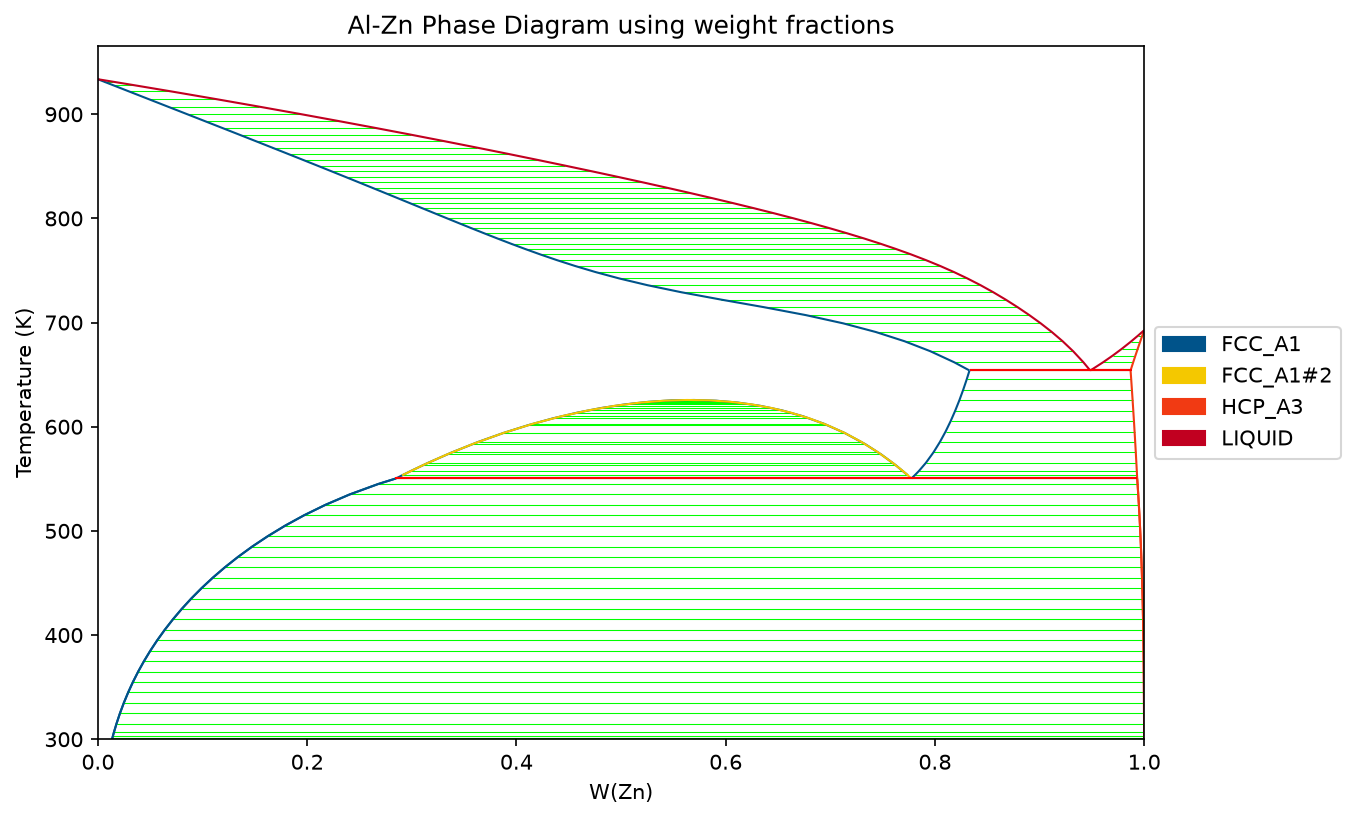

In [2]:
# Plotting in weight fraction
ax = plot_binary(binary, v.W('ZN'), v.T)
fig = ax.figure
ax.set_xlim([0, 1])
ax.set_title("Al-Zn Phase Diagram using weight fractions")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

Similarly, the same can be done for ternaries using TernaryStrategy and plot_ternary.

## Step plotting

Step mapping allows computing equilibrium along a single axis. By default, step plotting will plot phase fraction vs. variable axis, but this can be modified through plotting.

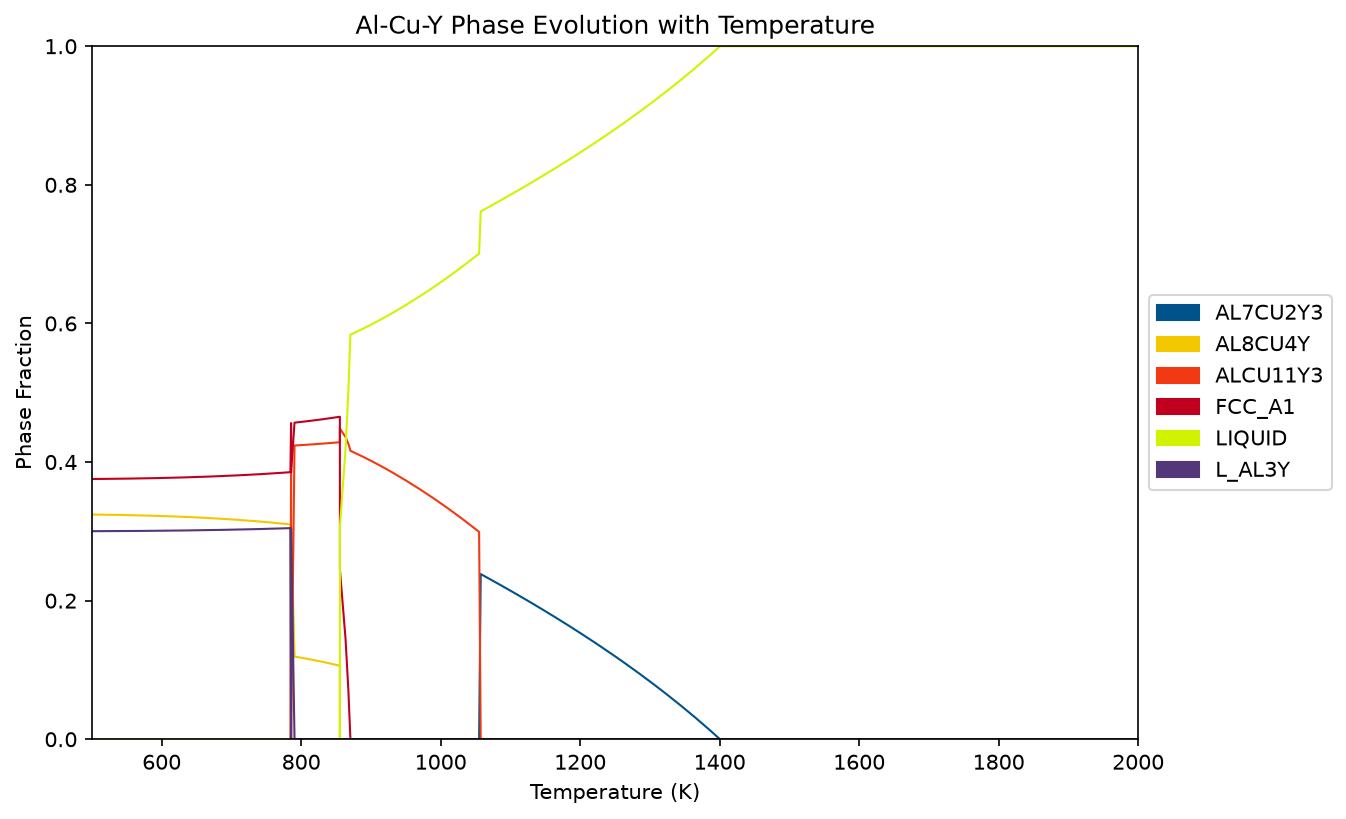

In [3]:
from pycalphad.mapping import StepStrategy, plot_step

dbf = Database('../databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
conds = {v.T: (500, 2000, 10), v.X('AL'): 0.8, v.X('CU'): 0.1, v.P: 101325, v.N: 1}

step = StepStrategy(dbf, comps, phases=None, conditions=conds)
step.do_map()

ax = plot_step(step)
fig = ax.figure
ax.set_title("Al-Cu-Y Phase Evolution with Temperature")
ax.set_xlim(500, 2000)
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

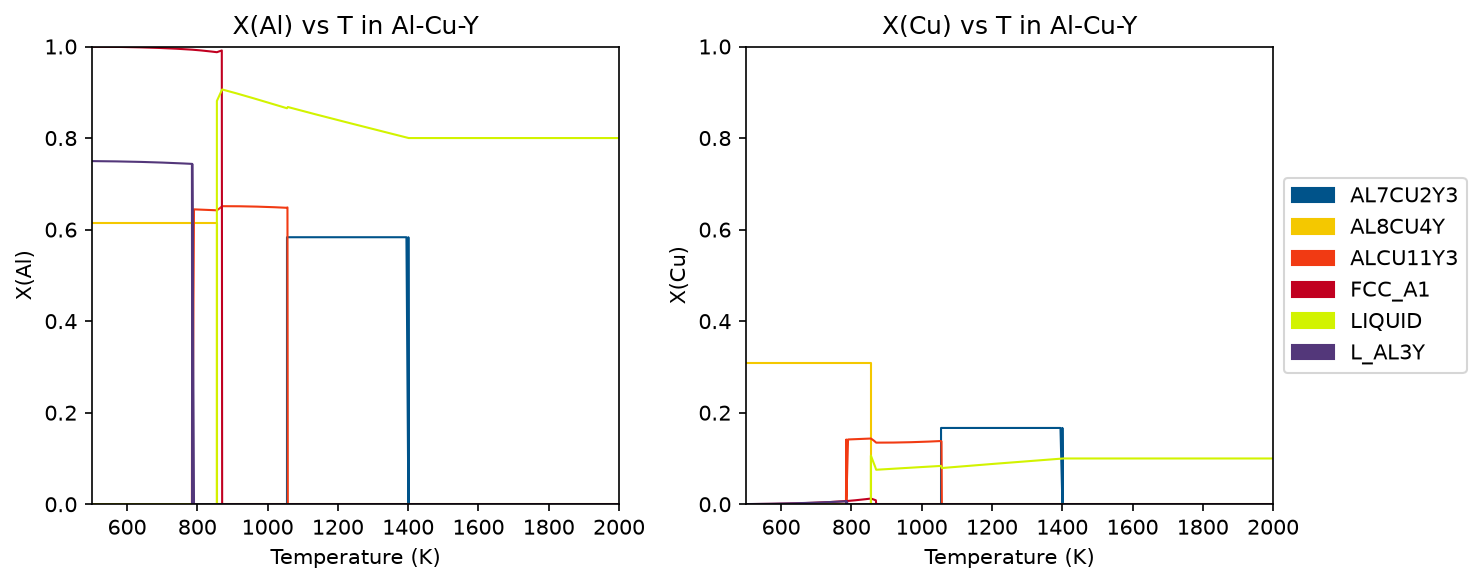

In [4]:
# Plotting composition of Al and Cu in each phase
fig, ax = plt.subplots(1, 2, figsize=(10,4))
plot_step(step, x=v.T, y=v.X('AL'), ax=ax[0])
plot_step(step, x=v.T, y=v.X('CU'), ax=ax[1])

ax[0].set_title("X(Al) vs T in Al-Cu-Y")
ax[0].set_xlim([500, 2000])
ax[0].set_ylim([0, 1])
ax[0].get_legend().remove()

ax[1].set_title("X(Cu) vs T in Al-Cu-Y")
ax[1].set_xlim([500, 2000])
ax[1].set_ylim([0, 1])
fig.tight_layout()
fig.set_dpi(150)
plt.show()

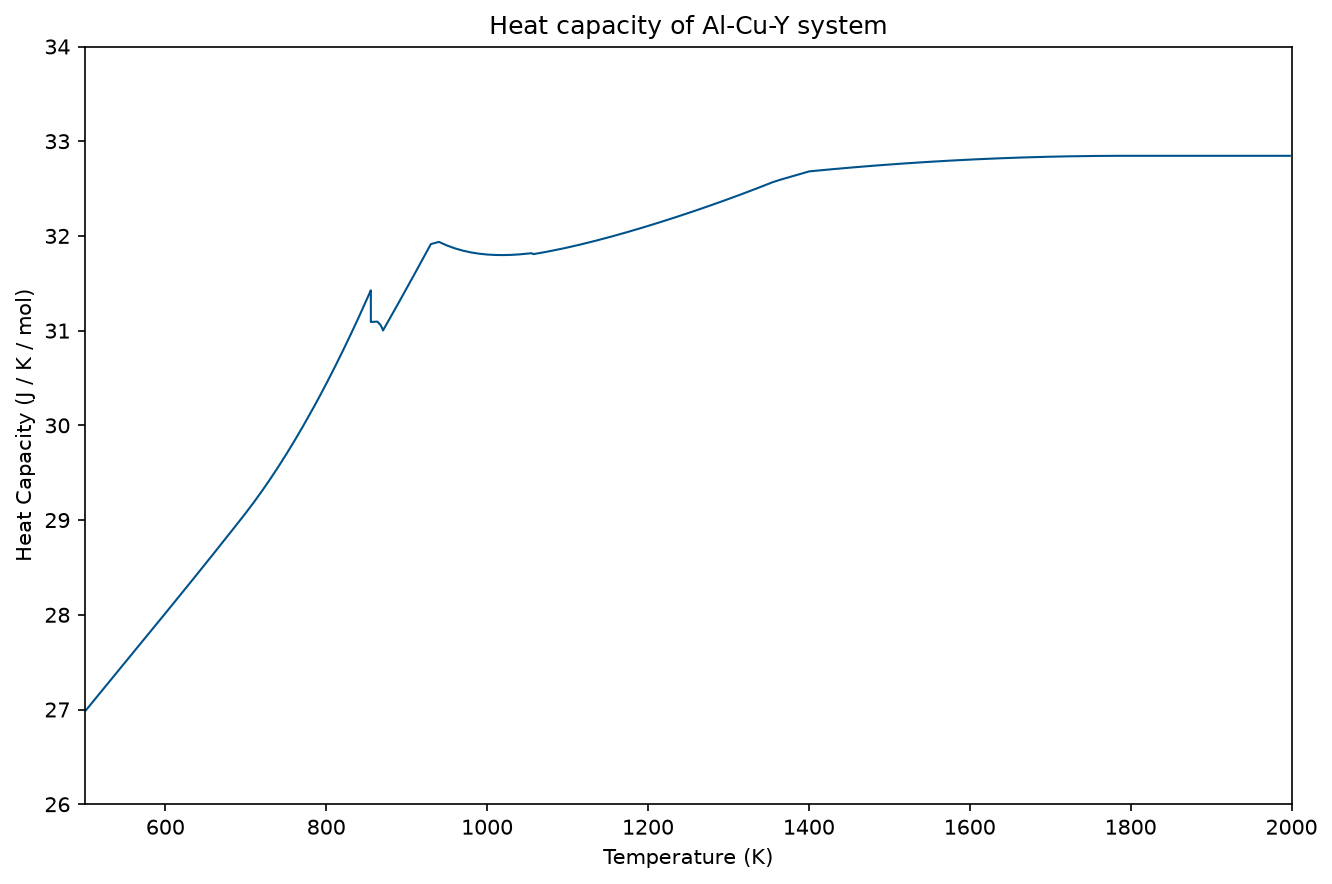

In [5]:
# Plotting heat capacity vs T
fig, ax = plt.subplots(figsize=(9,6))
plot_step(step, x=v.T, y='CPM', ax=ax)
ax.set_title("Heat capacity of Al-Cu-Y system")
ax.set_xlim([500, 2000])
ax.set_ylim([26, 34])
fig.tight_layout()

fig.set_dpi(150)
plt.show()

## Isopleth plotting

For multicomponent systems, isopleths can be computed and plotted.

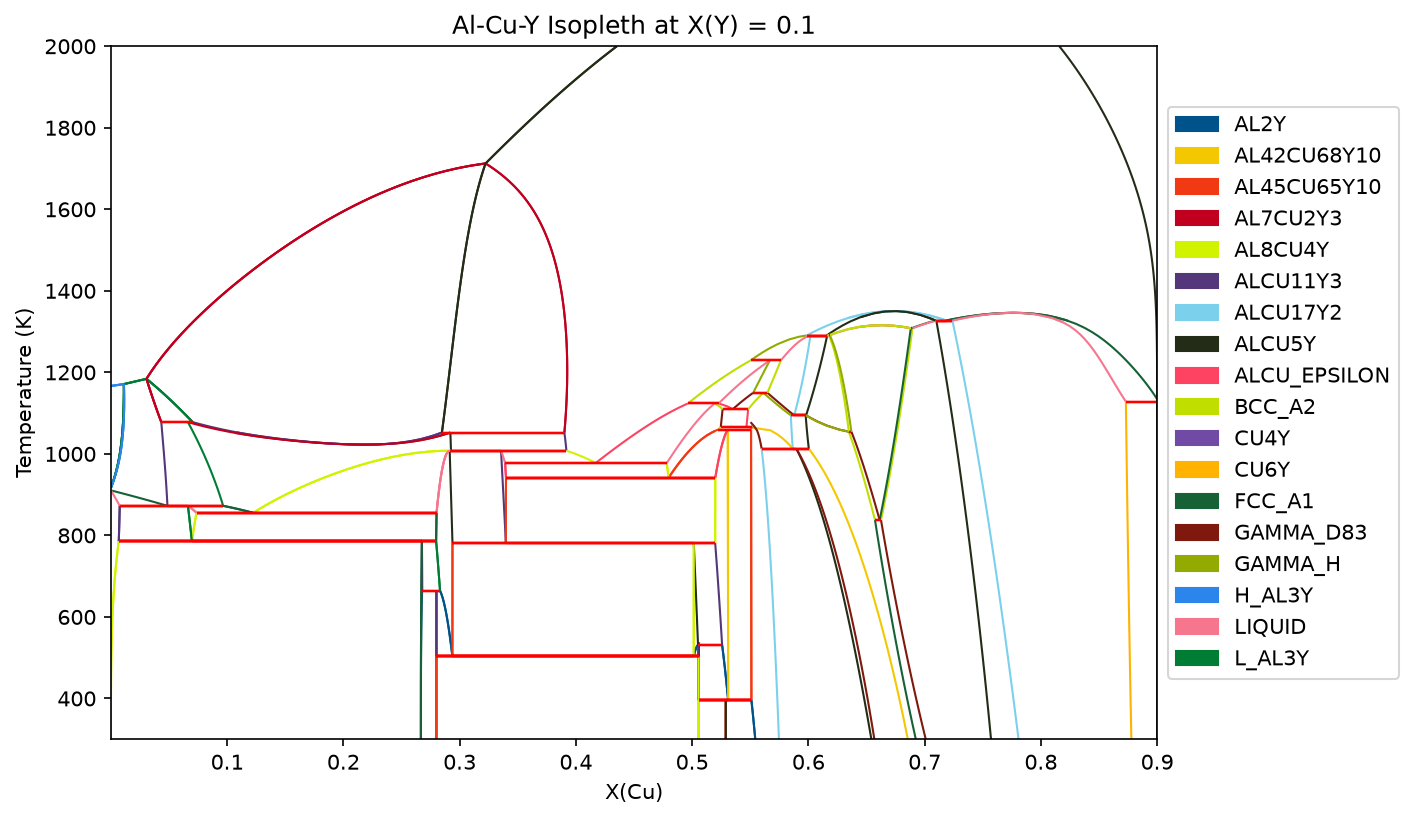

In [6]:
from pycalphad.mapping import IsoplethStrategy, plot_isopleth

dbf = Database('../databases/Al-Cu-Y.tdb')
comps = ['AL', 'CU', 'Y', 'VA']
conds = {v.T: (300, 2000, 10), v.P: 101325, v.N: 1, v.X('Y'): 0.1, v.X('CU'): (0, 1, 0.01)}

iso = IsoplethStrategy(dbf, comps, phases=None, conditions=conds)
iso.do_map()
ax = plot_isopleth(iso)
fig = ax.figure
ax.set_title("Al-Cu-Y Isopleth at X(Y) = 0.1")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

## Custom plotting

While the Mapping API provides built-in plotting functions, access to Mapping data is provided to build custom plotting functions. Below is an example to plot binary and ternary phase diagrams with shaded regions.

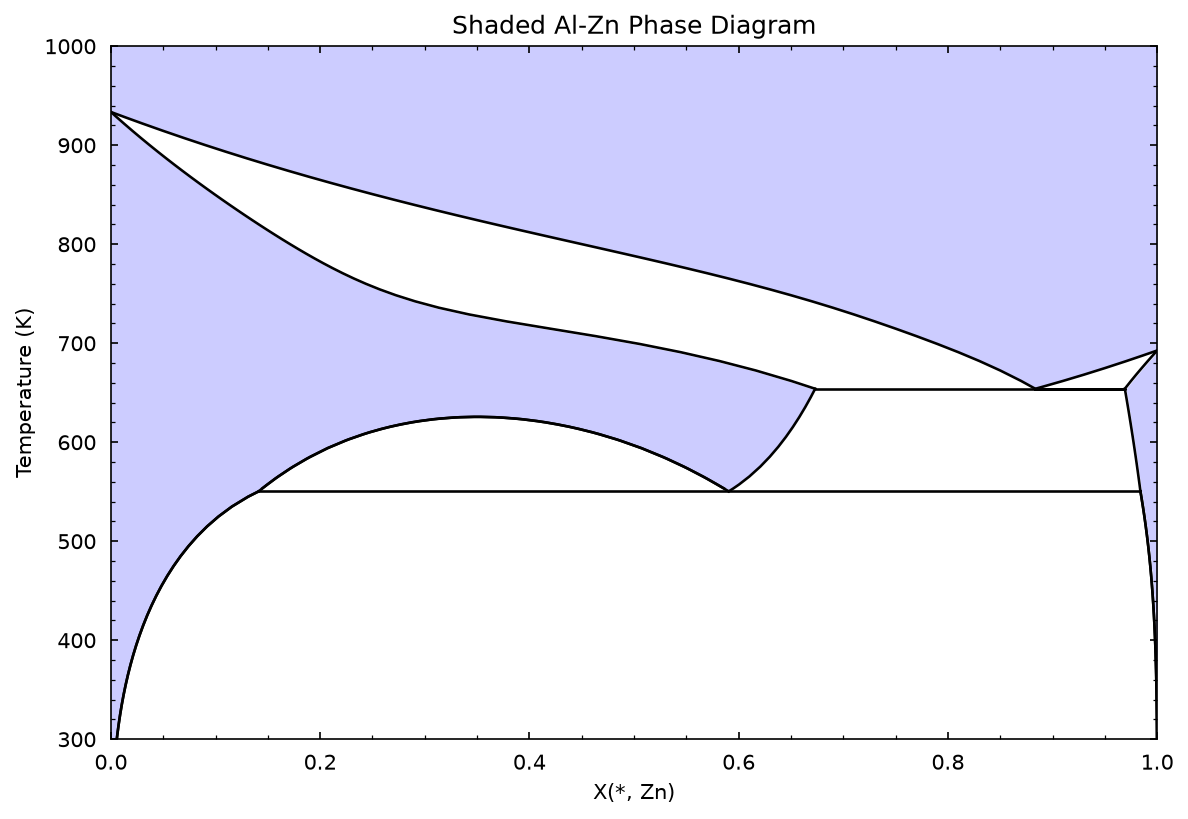

In [7]:
import numpy as np
from pycalphad.mapping.plotting import get_label

def plot_shaded_binary(strategy: BinaryStrategy, ax, single_phase_color = (0.8, 0.8, 1.0), two_phase_color = (1.0, 1.0, 1.0)):
    # Assume x is composition and y is temperature or pressure
    x = [var for var in strategy.axis_vars if var not in [v.N, v.P, v.T]][0]
    y = [var for var in strategy.axis_vars if var in [v.N, v.P, v.T]][0]

    # Anything that the tielines or invariants do not cover is single phase, so we can plot the entire region with the single phase color and add on top of it
    ax.fill_between(strategy.axis_lims[x], [strategy.axis_lims[y][0], strategy.axis_lims[y][0]], [strategy.axis_lims[y][1], strategy.axis_lims[y][1]], color=single_phase_color)

    # Plot invariant data. These are lines in a binary phase diagram, so we just have to plot as such
    inv_data = strategy.get_invariant_data(x, y)
    for inv in inv_data:
        ax.plot(inv.x, inv.y, color='k', linewidth=1.25, linestyle='-')

    # Plot tieline data. Each tieline has x,y for both phases, so we plot those as lines, then fill in between
    tie_data = strategy.get_tieline_data(x, y)
    for tie in tie_data:
        for ph, xp, yp in zip(tie.phases, tie.x, tie.y):
            ax.plot(xp, yp, color='k', linewidth=1.25, linestyle='-')
        ax.fill_betweenx(tie.y[0], tie.x[0], tie.x[1], color=two_phase_color)

    # Axis labels and limits
    ax.set_xlabel(get_label(x))
    ax.set_xlim(strategy.axis_lims[x])
    ax.set_ylabel(get_label(y))
    ax.set_ylim(strategy.axis_lims[y])

    # Add major and minor axis ticks on inside of plot
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in', bottom=True, top=True, left=True, right=True, pad=7)
    ax.tick_params(axis='both', which='major', direction='in', bottom=True, top=True, left=True, right=True, pad=7)

dbf = Database('../databases/alzn_mey.tdb')
comps = ['AL', 'ZN', 'VA']
conds = {v.N: 1, v.P:101325, v.T: (300, 1000, 10), v.X('ZN'):(0, 1, 0.02)}

# Phases will be automatically filtered with components if no phases are passed
binary = BinaryStrategy(dbf, comps, phases=None, conditions=conds)
binary.do_map()
fig, ax = plt.subplots()
plot_shaded_binary(binary, ax)
ax.set_title("Shaded Al-Zn Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()

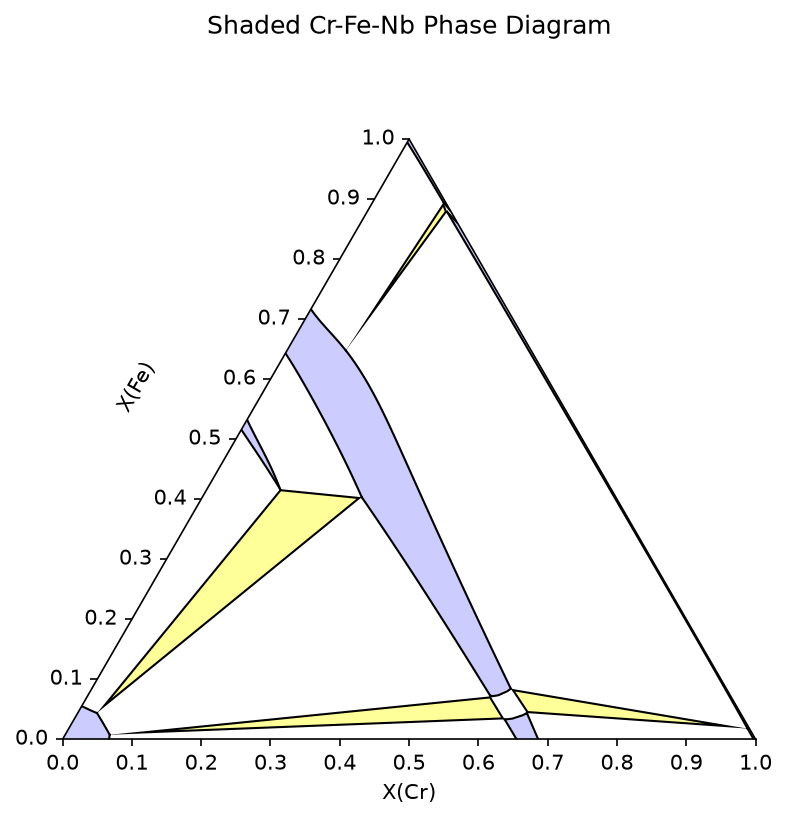

In [8]:
import matplotlib.patches as mp
from pycalphad.plot import triangular
from pycalphad.mapping import TernaryStrategy

def plot_shaded_ternary(strategy: TernaryStrategy, ax, x = None, y = None, single_phase_color = (0.8, 0.8, 1.0), two_phase_color = (1.0, 1.0, 1.0), three_phase_color = (1.0, 1.0, 0.6)):
    if x is None:
        x = strategy.axis_vars[0]
    if y is None:
        y = strategy.axis_vars[1]

    # Fill plot with single phase color since anything that the tieline and invariants do not cover is single phase
    ax.fill_between([0, 1], [0, 0], [1, 1], color=single_phase_color)

    # Plot invariant data. These are triangles, so we can add them as matplotlib patches
    inv_data = strategy.get_invariant_data(x, y)
    for inv in inv_data:
        triangle = mp.Polygon(np.array([inv.x, inv.y]).T, facecolor=three_phase_color, edgecolor='k', linewidth=2, joinstyle='bevel')
        ax.add_patch(triangle)

    # Plot tieline data. As with invariant data, we can add these as matplotlib patches
    # Depending on the starting points during mapping, a two-phase region can be split, so we
    # plot the patch without an outline, then plot the x, y data as a line afterwards
    tie_data = strategy.get_tieline_data(x, y)
    for tie in tie_data:
        xp = np.concatenate([tie.x[0], tie.x[1][::-1]])
        yp = np.concatenate([tie.y[0], tie.y[1][::-1]])
        polygon = mp.Polygon(np.array([xp, yp]).T, facecolor=two_phase_color)
        ax.add_patch(polygon)
        for i in range(len(tie.x)):
            ax.plot(tie.x[i], tie.y[i], color='k', linewidth=1)

    # Axis labels and limits
    ax.set_ylabel(get_label(y))
    ax.set_xlabel(get_label(x))
    ax.yaxis.label.set_rotation(60)
    ax.yaxis.set_label_coords(x=0.12, y=0.5)

dbf = Database('../databases/CrFeNb_Jacob2016.tdb')
comps = ['CR', 'FE', 'NB', 'VA']
phases = list(dbf.phases.keys())
conds = {v.T: 1323, v.P:101325, v.X('CR'): (0,1,0.015), v.X('FE'): (0,1,0.015)}

tern = TernaryStrategy(dbf, comps, phases, conds)
tern.do_map()
fig, ax = plt.subplots(subplot_kw={'projection': 'triangular'})
plot_shaded_ternary(tern, ax, v.X('CR'), v.X('FE'))
ax.set_title("Shaded Cr-Fe-Nb Phase Diagram")
fig.set_size_inches(9, 6)
fig.set_dpi(150)
plt.show()